## <center> **Separate Prefill and Decode** <center>
Using one (or possibly more) of the *conversational* traces, consider the interactions at the **session level** to produce traces that: in the case of prefill only consider the new prompt (i.e., the new question), which will be relevant for the *computation-intensive* complexity evaluation part, while for the decode it considers the entire context (previous questions and answers + current question) for the *memory-intensive* part.

#

### Goal: a per-message dataset from WildChat-1M

Starting from **WildChat-1M** (real user/assistant conversations), we build a **long-format** table with **one row per message (utterance)**:

| Column | Meaning |
|---|---|
| `session_id` | Unique id of the conversation/session. We use the conversation's row index in the dataset, since `conversation_hash` is **not** guaranteed unique. |
| `conversation_hash` | Original WildChat hash (kept for reference, not unique). |
| `message_index` | 0-based position of the message within its session. |
| `role` | `user` or `assistant`. |
| `n_tokens` | Number of tokens of *this* message's `content`. |
| `model` | OpenAI model of the conversation (selects the tokenizer). |

This minimal schema lets us reconstruct **both** quantities of interest:

- **Current content only** (prefill / *compute-intensive*): for a `user` message, `n_tokens` is exactly the standalone new question.
- **Entire context** (decode / *memory-intensive*): the cumulative sum of `n_tokens` over all earlier messages in the session **plus** the current one — i.e. all previous Q&A + the current question that the model actually attends to.

> **Note on tokenization.** We tokenize each message's `content` independently and sum. The cumulative sum is a close approximation of the full-context length; it does not include chat-template formatting overhead and may differ by a few tokens from tokenizing the whole concatenated history at once. This per-message granularity is the right primitive for KV-cache / context-size modeling.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datasets import load_from_disk

BASE_DIR = Path(".")
CACHE = BASE_DIR / "_cache"
CACHE.mkdir(exist_ok=True)

wildchat = load_from_disk(str(BASE_DIR / "wildchat"))
df_wildchat = wildchat["train"].to_pandas()                   # NOTE: here only the *training part*
print(f"Conversations: {len(df_wildchat):,}")
df_wildchat[["conversation_hash", "model", "turn"]].head()

# loading + to_pandas() ~ 2 min

Conversations: 837,989


,conversation_hash,model,turn
0,c9ec5b440fbdd2a269333dd241f32f64,gpt-4-0314,1
1,34f1581760df304d539e2fe4653b40d3,gpt-4-0314,2
2,cf1267ca6b2f6fccc9c36652a00059a1,gpt-4-0314,1
3,7f1c97a4f873cda8106b010d040be078,gpt-4-0314,1
4,e98d3e74c57f9a65261df393d9124ac2,gpt-4-0314,1


#

### Tokenizer

We mirror the choice made in `traces_comparison_raw.ipynb`: use `tiktoken` with the model-specific encoding, falling back to `cl100k_base` for unknown variants. `disallowed_special=()` treats special-token strings in user content as plain text.

In [2]:
import tiktoken
from functools import lru_cache

@lru_cache(maxsize=16)
def get_encoder(model_name):
    try:
        return tiktoken.encoding_for_model(model_name)
    except KeyError:
        return tiktoken.get_encoding("cl100k_base")

def count_tokens(enc, text):
    return len(enc.encode(text, disallowed_special=()))

def model_family(model_name):
    if model_name.startswith("gpt-4"):
        return "GPT-4"
    if model_name.startswith("gpt-3.5"):
        return "GPT-3.5-turbo"
    return "Other"

#

### Build the per-message table

We iterate over every conversation, assign it a unique `session_id` (its row index), and emit one row per message with its token count. Result is cached to `_cache/wildchat_messages.parquet`.

In [3]:
from tqdm.notebook import tqdm

def extract_messages(session_id, conversation_hash, conversation, model):
    enc = get_encoder(model)
    rows = []
    for msg_idx, msg in enumerate(conversation):
        content = msg.get("content") or ""
        rows.append({
            "session_id": session_id,
            "conversation_hash": conversation_hash,
            "message_index": msg_idx,
            "role": msg["role"],
            "n_tokens": count_tokens(enc, content),
            "model": model,
        })
    return rows

MESSAGES_PARQUET = CACHE / "wildchat_messages.parquet"

if MESSAGES_PARQUET.exists():
    df_messages = pd.read_parquet(MESSAGES_PARQUET)
else:
    all_rows = []
    for session_id, row in tqdm(
        enumerate(df_wildchat.itertuples(index=False)),
        total=len(df_wildchat),
        desc="Tokenizing WildChat messages",
    ):
        all_rows.extend(
            extract_messages(session_id, row.conversation_hash, row.conversation, row.model)
        )
    df_messages = pd.DataFrame(all_rows)
    df_messages.to_parquet(MESSAGES_PARQUET, index=False)

print(f"Total messages: {len(df_messages):,}  |  sessions: {df_messages['session_id'].nunique():,}")
df_messages.head(8)

# tokenizing all messages ~ 10-15 min if not cached

Total messages: 3,920,148  |  sessions: 837,989


,session_id,conversation_hash,message_index,role,n_tokens,model
0,0,c9ec5b440fbdd2a269333dd241f32f64,0,user,307,gpt-4-0314
1,0,c9ec5b440fbdd2a269333dd241f32f64,1,assistant,650,gpt-4-0314
2,1,34f1581760df304d539e2fe4653b40d3,0,user,16,gpt-4-0314
3,1,34f1581760df304d539e2fe4653b40d3,1,assistant,209,gpt-4-0314
4,1,34f1581760df304d539e2fe4653b40d3,2,user,24,gpt-4-0314
5,1,34f1581760df304d539e2fe4653b40d3,3,assistant,257,gpt-4-0314
6,2,cf1267ca6b2f6fccc9c36652a00059a1,0,user,37,gpt-4-0314
7,2,cf1267ca6b2f6fccc9c36652a00059a1,1,assistant,69,gpt-4-0314


#

#

### Dataset Construction

`context_tokens` = cumulative token count within a session up to **and including** the current message. This is the full input the model attends to at that point (all prior Q&A + current message).

We want a single dataset organized in terms of input-output-context tokens
- for the **prefill** (compute-intensive) we will consider only the *current message* (i.e., prompt tokens of user-role) `n_tokens` → the standalone new question
- the **decode** will need to consider all the `context_tokens` → the memory footprint 

The dataframe will have the following columns:
-  `session_id`: unique id of the conversation/session (row index in the dataset)
-  `message_index`: 0-based position of the message within its session
- `prompt_tokens`: number of tokens of the current message's content (to be considered for prefill / compute-intensive)
- `context_tokens`: cumulative token count within a session up to **and including** the current message
- `output_tokens`: number of tokens of the **assistant's response** (to be considered for decode / memory-intensive)
- `model`: OpenAI model of the conversation (selects the tokenizer)

In [4]:
# Order messages within each session (already in order, but make it explicit)
df = df_messages.sort_values(["session_id", "message_index"]).reset_index(drop=True)

# context_tokens: cumulative tokens within a session, up to AND including the current message
#                 (all prior Q&A + current message) -> decode / memory footprint
df["context_tokens"] = df.groupby("session_id")["n_tokens"].cumsum()

# For a user turn, the assistant's response is the next message in the same session.
df["next_role"]   = df.groupby("session_id")["role"].shift(-1)
df["next_tokens"] = df.groupby("session_id")["n_tokens"].shift(-1)

# Keep one row per user turn (a request): prompt = current question, output = assistant reply
user_turns = df[df["role"] == "user"].copy()
user_turns["prompt_tokens"] = user_turns["n_tokens"]                       # prefill / compute-intensive
user_turns["output_tokens"] = np.where(                                    # decode output length
    user_turns["next_role"] == "assistant", user_turns["next_tokens"], 0
).astype(int)

dataset = user_turns[
    ["session_id", "message_index", "prompt_tokens", "context_tokens", "output_tokens", "model"]
].reset_index(drop=True)

print(f"Requests (user turns): {len(dataset):,}  |  sessions: {dataset['session_id'].nunique():,}")
dataset.head(8)

Requests (user turns): 1,960,074  |  sessions: 837,989


,session_id,message_index,prompt_tokens,context_tokens,output_tokens,model
0,0,0,307,307,650,gpt-4-0314
1,1,0,16,16,209,gpt-4-0314
2,1,2,24,249,257,gpt-4-0314
3,2,0,37,37,69,gpt-4-0314
4,3,0,76,76,176,gpt-4-0314
5,4,0,317,317,706,gpt-4-0314
6,5,0,35,35,444,gpt-4-0314
7,5,2,24,503,523,gpt-4-0314


In [5]:
# Sanity check on one multi-turn session: context grows, output = next assistant reply
sid = dataset[dataset.duplicated("session_id", keep=False)]["session_id"].iloc[0]
print(f"session_id = {sid}  (full message view)")
display(df_messages[df_messages["session_id"] == sid][["message_index", "role", "n_tokens"]])
print("Resulting per-request rows:")
dataset[dataset["session_id"] == sid]

session_id = 1  (full message view)


,message_index,role,n_tokens
2,0,user,16
3,1,assistant,209
4,2,user,24
5,3,assistant,257


Resulting per-request rows:


,session_id,message_index,prompt_tokens,context_tokens,output_tokens,model
1,1,0,16,16,209,gpt-4-0314
2,1,2,24,249,257,gpt-4-0314


In [6]:
# Summary statistics and persist the dataset
rows = []
for col, label in [
    ("prompt_tokens",  "prompt_tokens (prefill / compute)"),
    ("context_tokens", "context_tokens (decode / memory)"),
    ("output_tokens",  "output_tokens (decode output len)"),
]:
    s = dataset[col]
    rows.append({
        "Metric": label,
        "Mean": f"{s.mean():.0f}", "p50": f"{s.quantile(.5):.0f}",
        "p90": f"{s.quantile(.9):.0f}", "p99": f"{s.quantile(.99):.0f}",
        "Max": f"{int(s.max())}",
    })
display(pd.DataFrame(rows).set_index("Metric"))

OUT = CACHE / "wildchat_prefill_decode.parquet"
dataset.to_parquet(OUT, index=False)
print("Saved:", OUT)

,Mean,p50,p90,p99,Max
Metric,,,,,
prompt_tokens (prefill / compute),247,28,685,3133,123628
context_tokens (decode / memory),1498,546,3192,17664,127722
output_tokens (decode output len),400,336,820,1546,4175


Saved: _cache\wildchat_prefill_decode.parquet


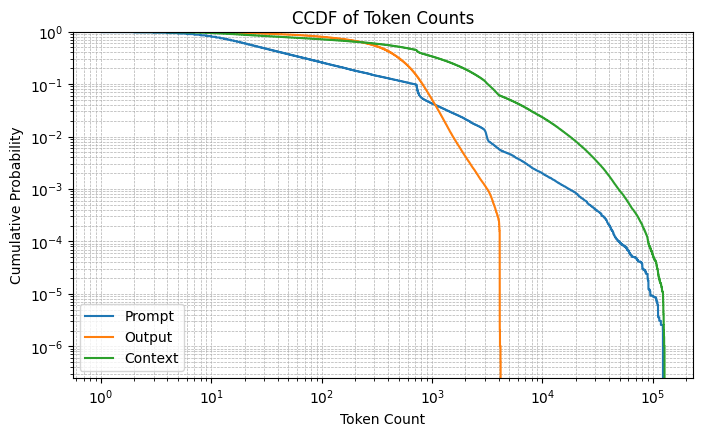

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# plot ccdf of input, output and context tokens
plt.figure(figsize=(8, 4.5))
sns.ecdfplot(data=dataset, x="prompt_tokens", label="Prompt", complementary=True)
sns.ecdfplot(data=dataset, x="output_tokens", label="Output", complementary=True)
sns.ecdfplot(data=dataset, x="context_tokens", label="Context", complementary=True)
plt.xlabel("Token Count")
plt.ylabel("Cumulative Probability")
plt.title("CCDF of Token Counts")
plt.xscale("log")
plt.yscale("log")
plt.legend(loc="lower left")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

In [9]:
dataset

,session_id,message_index,prompt_tokens,context_tokens,output_tokens,model
0,0,0,307,307,650,gpt-4-0314
1,1,0,16,16,209,gpt-4-0314
2,1,2,24,249,257,gpt-4-0314
3,2,0,37,37,69,gpt-4-0314
4,3,0,76,76,176,gpt-4-0314
...,...,...,...,...,...,...
1960069,837984,8,11,759,248,gpt-3.5-turbo-0125
1960070,837985,0,16164,16164,666,gpt-4-0125-preview
1960071,837986,0,1399,1399,1069,gpt-4-0125-preview
1960072,837987,0,8704,8704,947,gpt-4-0125-preview


In [ ]:
# convert the parquet file into a csv and save it
OUT = CACHE / "wildchat_dataset.csv"
dataset.to_csv(OUT, index=False)
print("Saved:", OUT)

Saved: _cache\dataset.csv
